In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import auc
from matplotlib.lines import Line2D
from pathlib import Path
import pandas as pd

In [12]:
base = "/home/users/mendrika/Object-Based-LSTMConv/outputs/initiation/corrected/"

In [13]:
lead_times = [30, 60, 90, 120]
radii = [30, 50]
colors = {30: "tab:blue", 50: "tab:orange"}

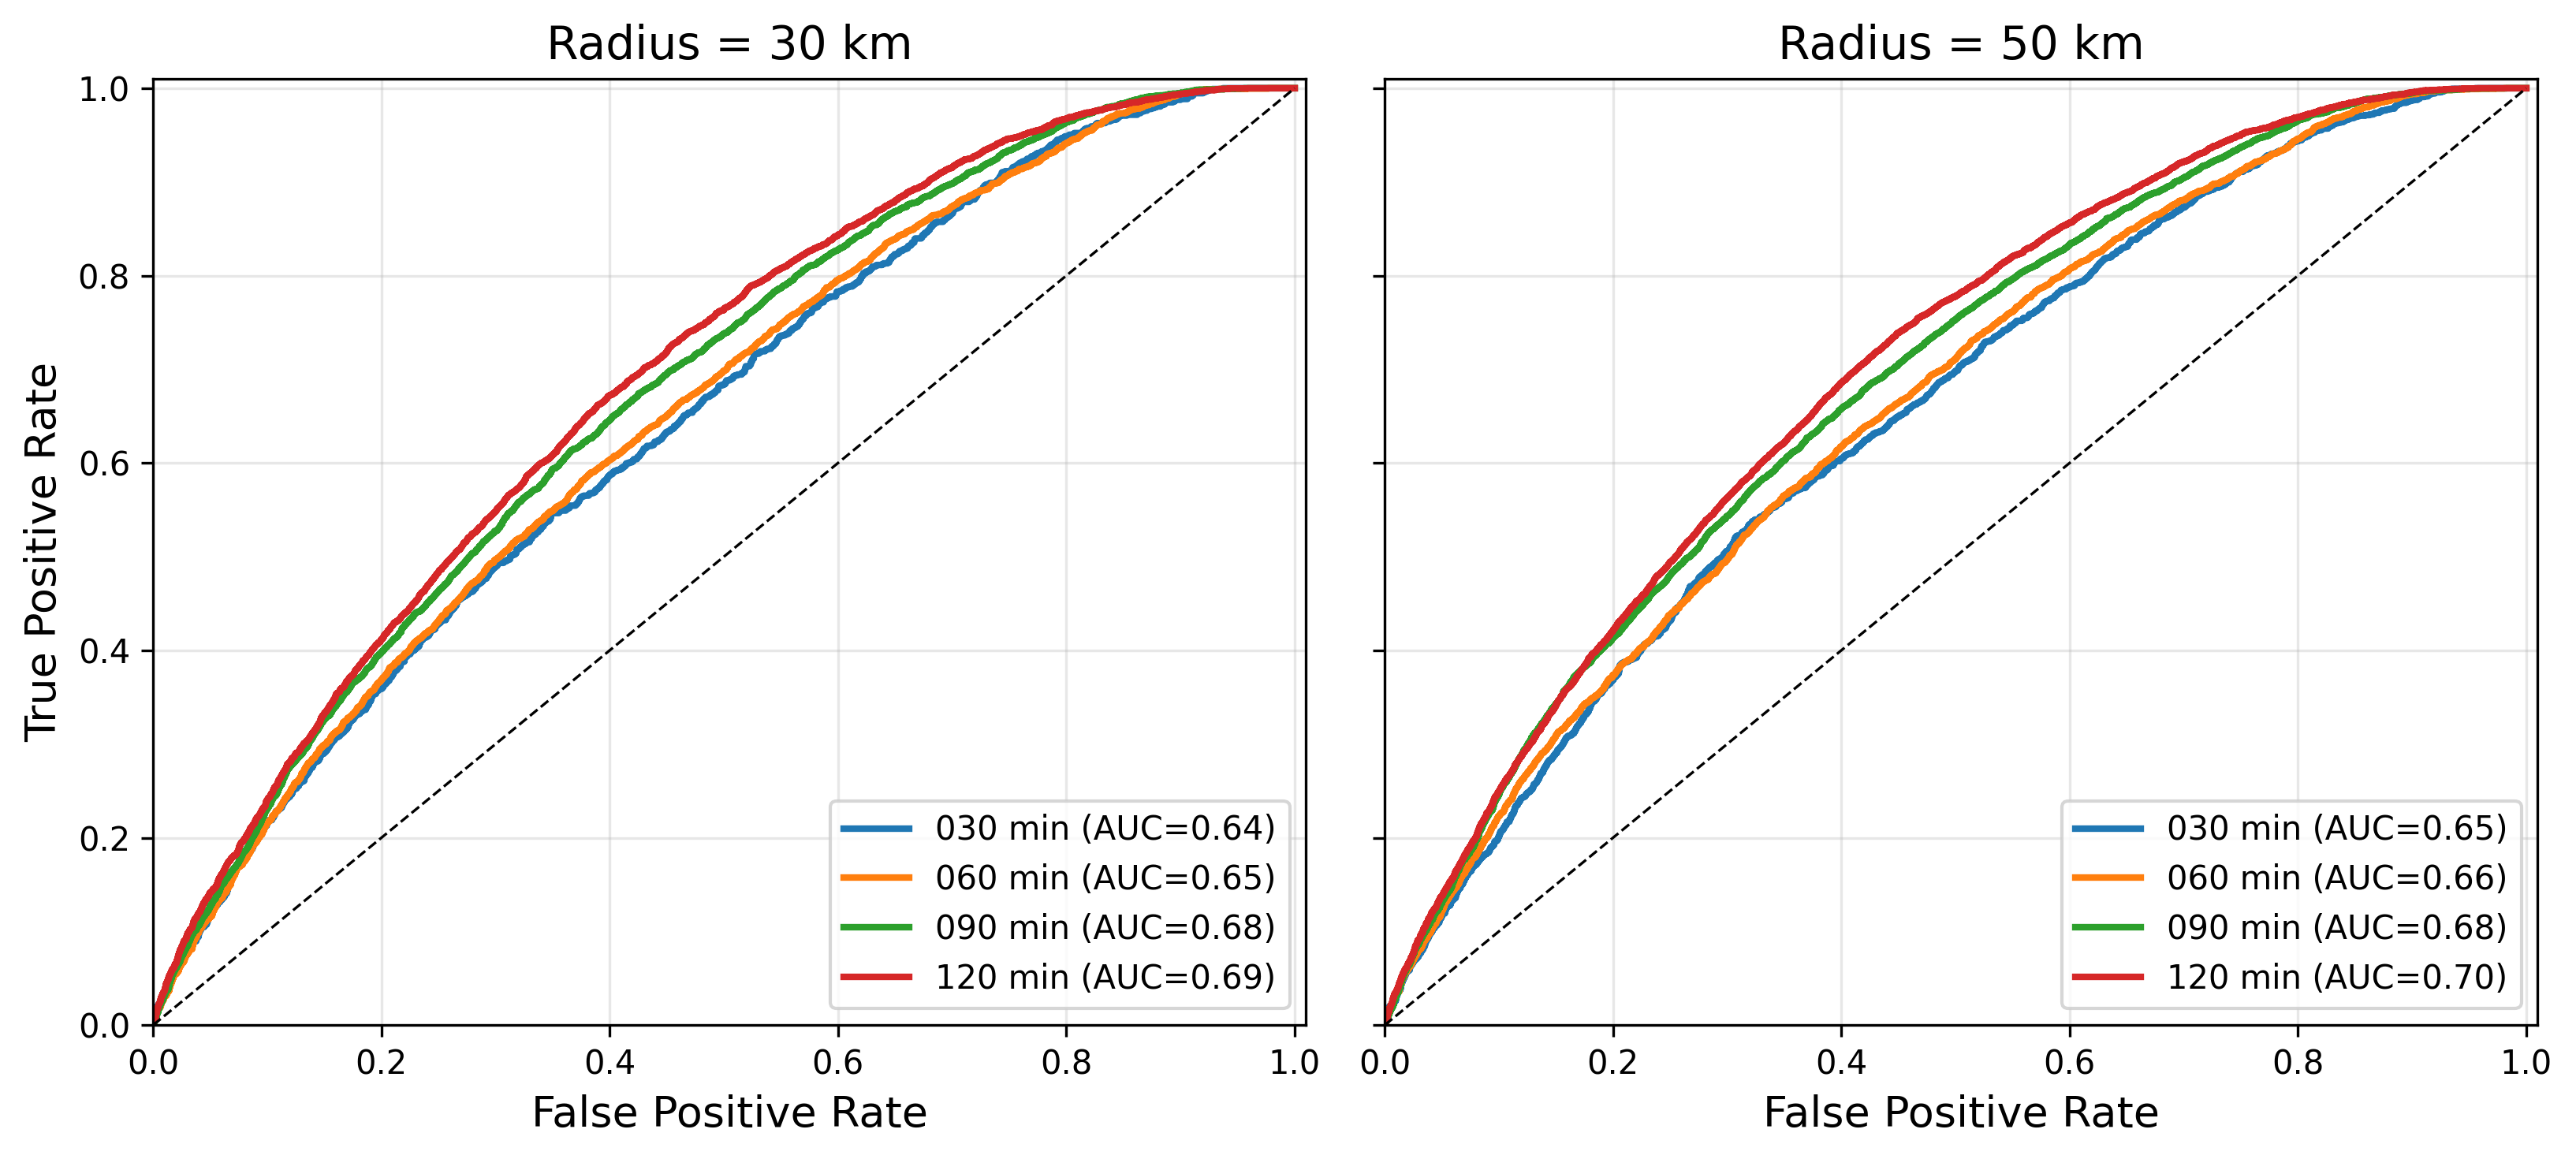

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), dpi=300, sharex=True, sharey=True)

for ax, RADIUS in zip(axes, radii):
    for lt in lead_times:
        fn = f"{base}/roc_ci_{RADIUS}_t{lt:03d}min.npz"
        data = np.load(fn)

        fpr = data["fpr"]
        tpr = data["tpr"]
        roc_auc = auc(fpr, tpr)

        ax.plot(
            fpr,
            tpr,
            linewidth=2,
            label=f"{lt:03d} min (AUC={roc_auc:.2f})"
        )

    # no-skill line
    ax.plot([0, 1], [0, 1], "k--", linewidth=0.8)

    ax.set_title(f"Radius = {RADIUS} km", fontsize=14)
    ax.set_xlim(0, 1.01)
    ax.set_ylim(0, 1.01)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=10, loc="lower right")

axes[0].set_ylabel("True Positive Rate", fontsize=13)
axes[0].set_xlabel("False Positive Rate", fontsize=13)
axes[1].set_xlabel("False Positive Rate", fontsize=13)

plt.tight_layout()
plt.show()

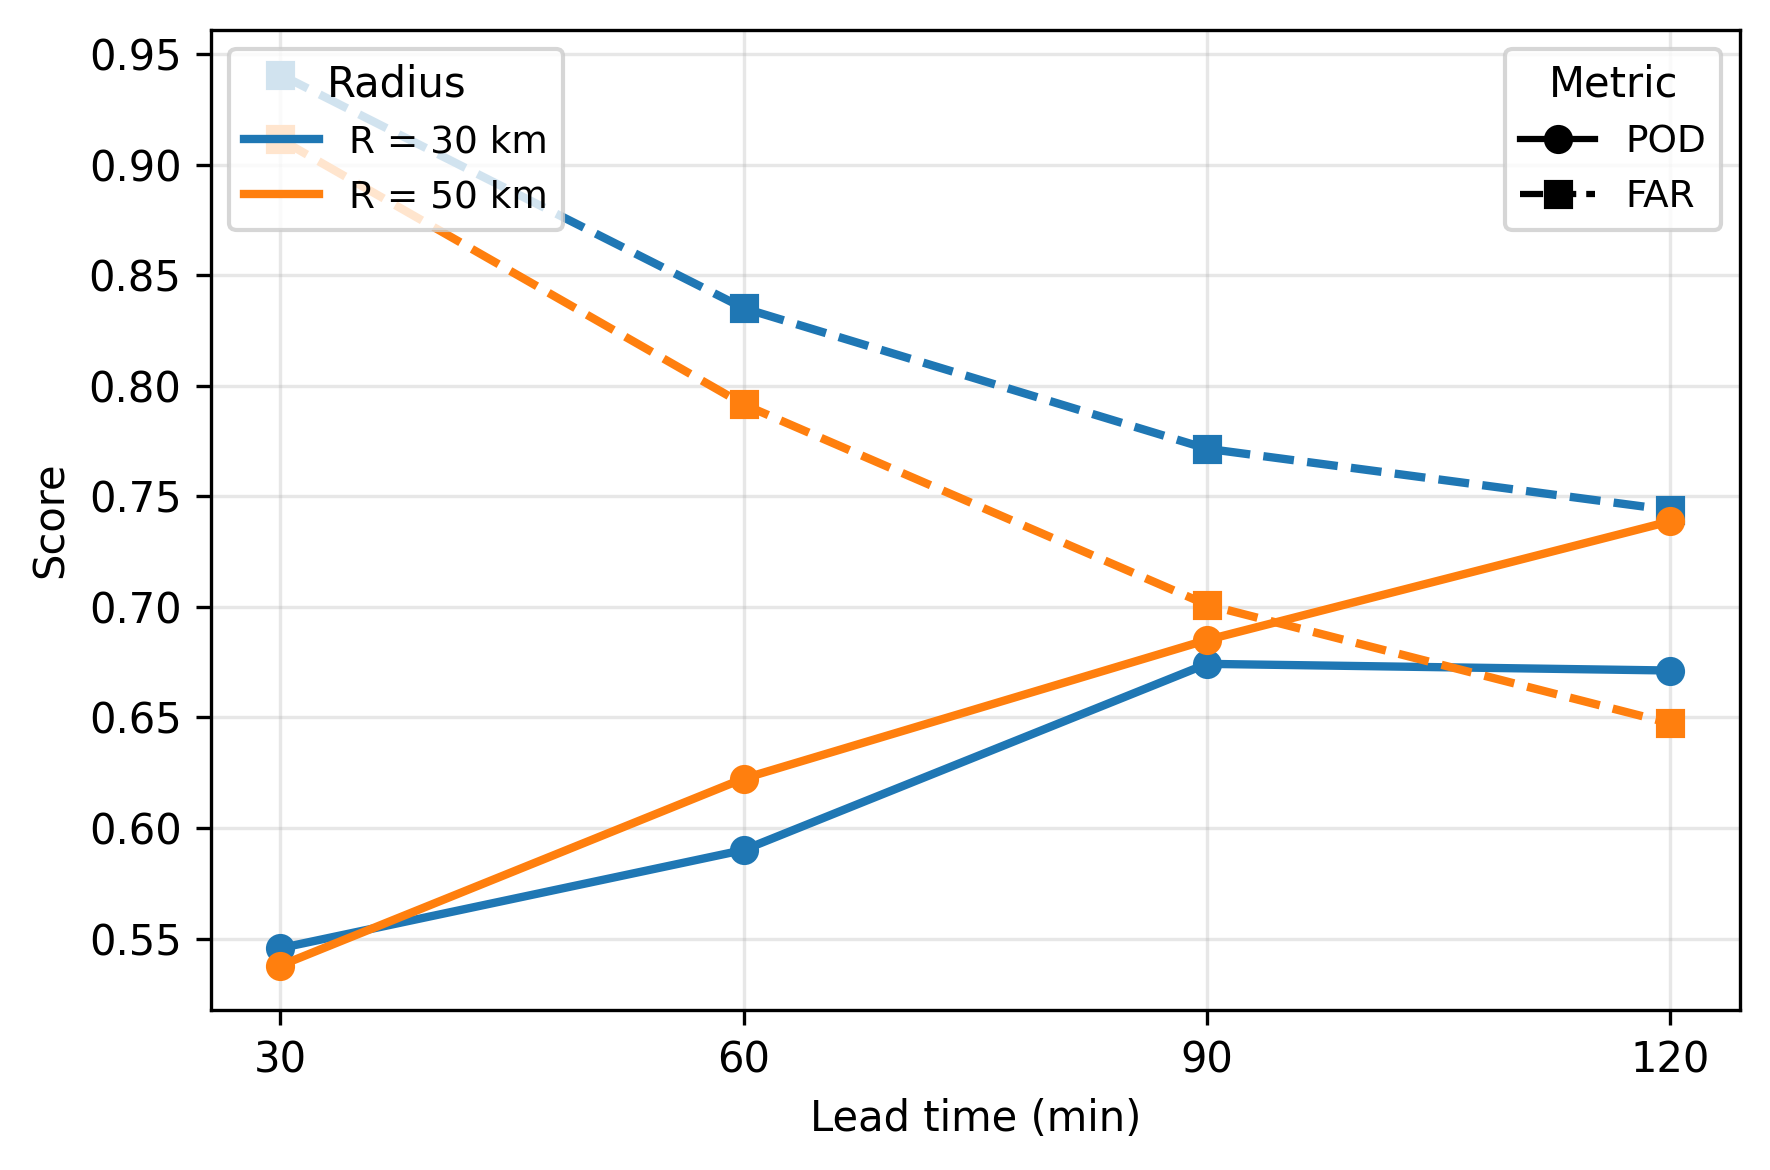

In [15]:
linestyles = {"POD": "-", "FAR": "--"}
markers = {"POD": "o", "FAR": "s"}

plt.figure(figsize=(6, 4), dpi=300)

for RADIUS in radii:
    files = sorted(Path(base).glob(f"ci_contingency_youden_R{RADIUS}_t*min.csv"))
    df = pd.concat(pd.read_csv(f) for f in files)

    plt.plot(
        df["lead_time_min"],
        df["POD"],
        color=colors[RADIUS],
        linestyle=linestyles["POD"],
        marker=markers["POD"],
        linewidth=2,
    )

    plt.plot(
        df["lead_time_min"],
        df["FAR"],
        color=colors[RADIUS],
        linestyle=linestyles["FAR"],
        marker=markers["FAR"],
        linewidth=2,
    )

plt.xticks(lead_times)
plt.xlabel("Lead time (min)")
plt.ylabel("Score")
plt.grid(alpha=0.3)

# Metric legend (line style + marker)
metric_legend = [
    Line2D([0], [0], color="black", linestyle="-", marker="o", label="POD"),
    Line2D([0], [0], color="black", linestyle="--", marker="s", label="FAR"),
]

# Radius legend (colour)
radius_legend = [
    Line2D([0], [0], color=colors[30], linewidth=2, label="R = 30 km"),
    Line2D([0], [0], color=colors[50], linewidth=2, label="R = 50 km"),
]

leg1 = plt.legend(
    handles=metric_legend,
    title="Metric",
    loc="upper right",
    fontsize=9,
)

leg2 = plt.legend(
    handles=radius_legend,
    title="Radius",
    loc="upper left",
    fontsize=9,
)

plt.gca().add_artist(leg1)

plt.tight_layout()
plt.show()


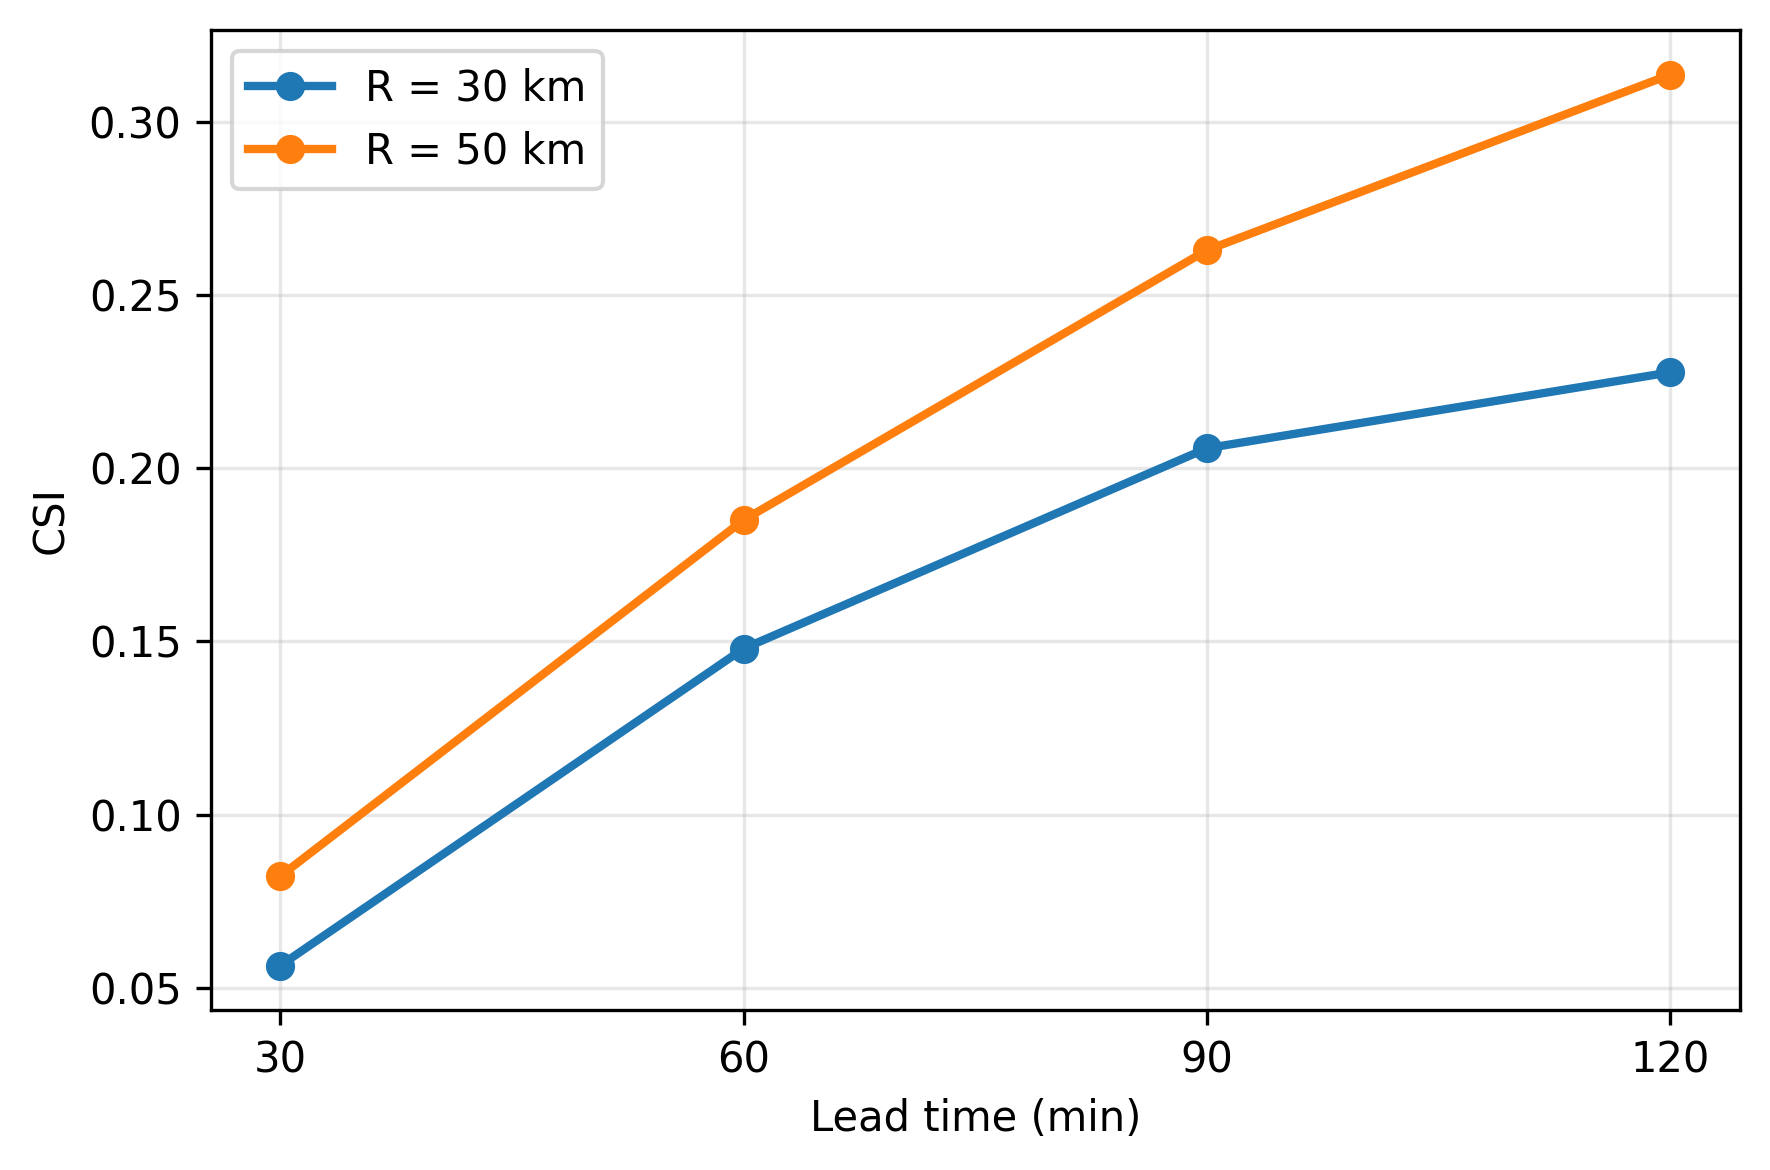

In [16]:
plt.figure(figsize=(6, 4), dpi=300)

for RADIUS in radii:
    files = sorted(Path(base).glob(f"ci_contingency_youden_R{RADIUS}_t*min.csv"))
    df = pd.concat(pd.read_csv(f) for f in files)

    df["CSI"] = df["hits"] / (
        df["hits"] + df["misses"] + df["false_alarms"]
    )

    plt.plot(
        df["lead_time_min"],
        df["CSI"],
        color=colors[RADIUS],
        marker="o",
        linewidth=2,
        label=f"R = {RADIUS} km",
    )

plt.xticks(lead_times)
plt.xlabel("Lead time (min)")
plt.ylabel("CSI")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

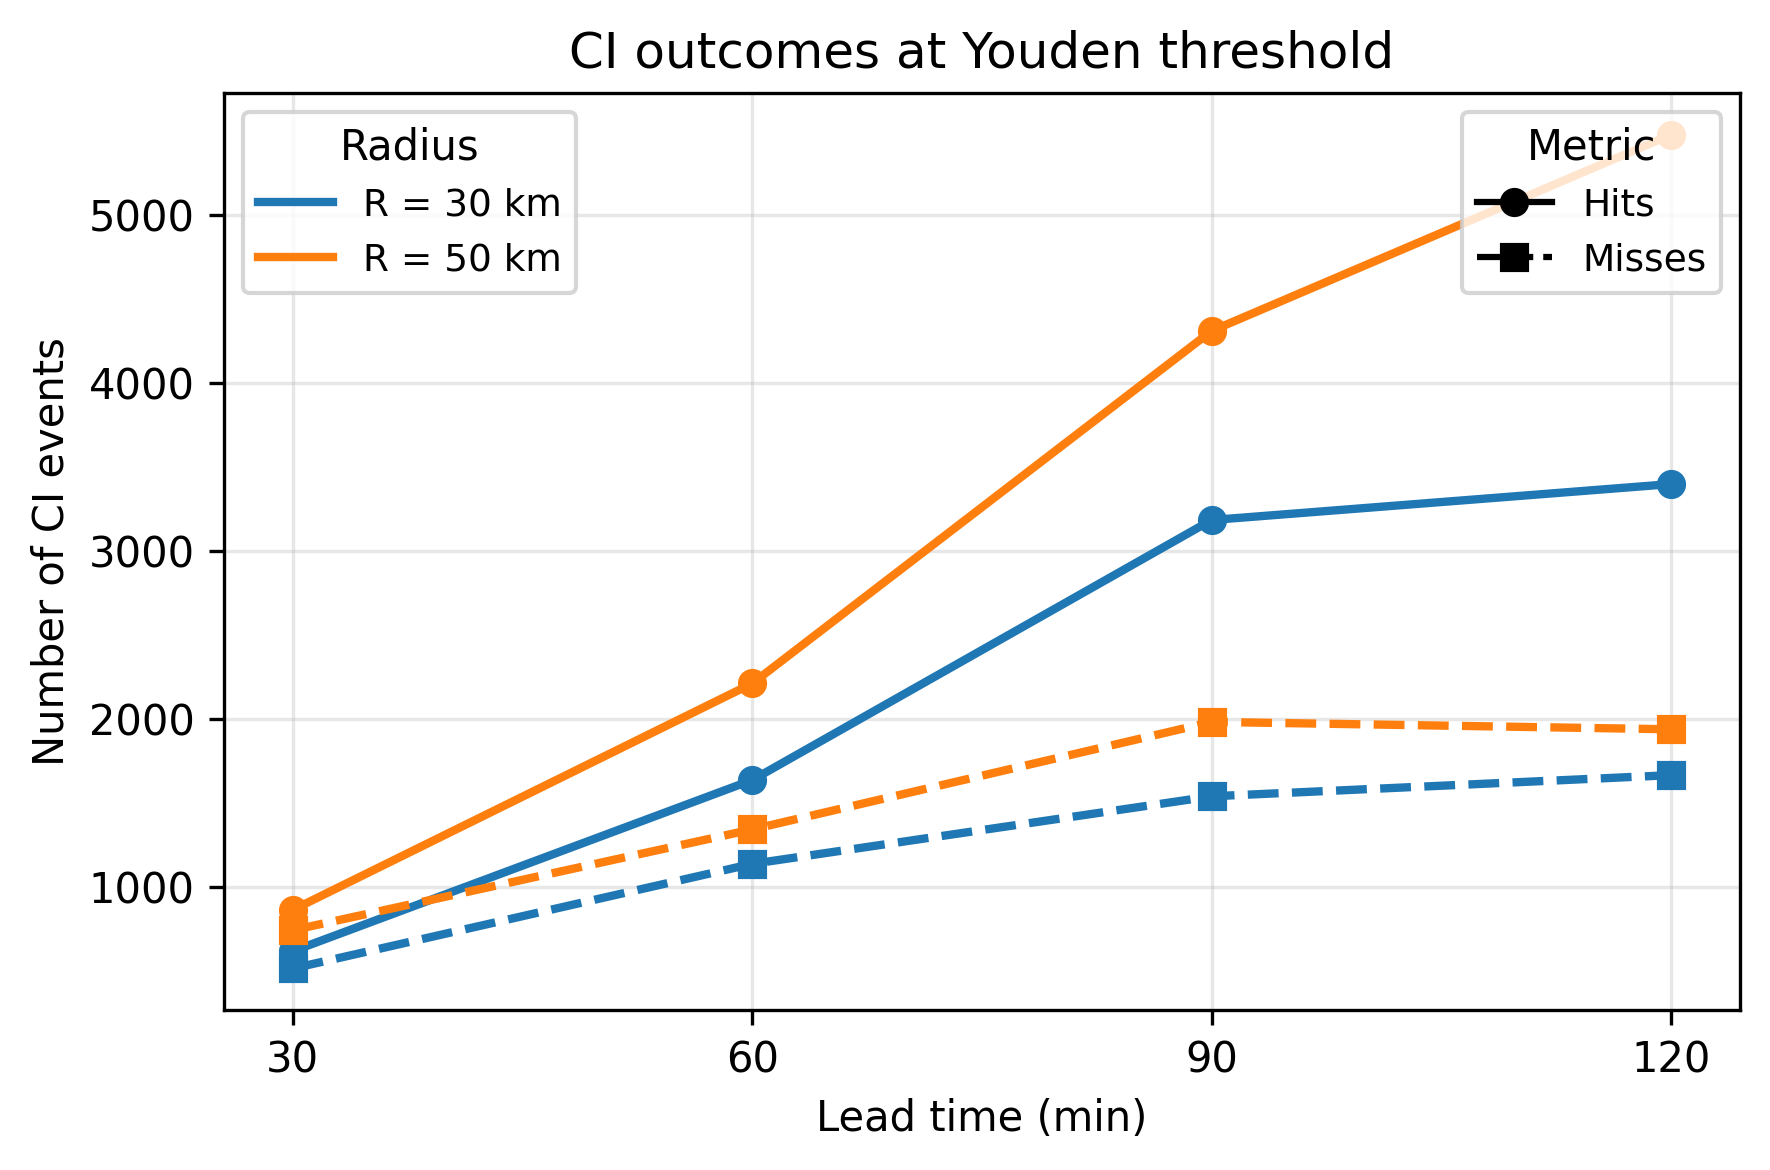

In [17]:
linestyles = {"Hits": "-", "Misses": "--"}
markers = {"Hits": "o", "Misses": "s"}

plt.figure(figsize=(6, 4), dpi=300)

for RADIUS in radii:
    files = sorted(Path(base).glob(f"ci_contingency_youden_R{RADIUS}_t*min.csv"))
    df = pd.concat(pd.read_csv(f) for f in files)

    plt.plot(
        df["lead_time_min"],
        df["hits"],
        color=colors[RADIUS],
        linestyle=linestyles["Hits"],
        marker=markers["Hits"],
        linewidth=2,
    )

    plt.plot(
        df["lead_time_min"],
        df["misses"],
        color=colors[RADIUS],
        linestyle=linestyles["Misses"],
        marker=markers["Misses"],
        linewidth=2,
    )

plt.xticks(lead_times)
plt.xlabel("Lead time (min)")
plt.ylabel("Number of CI events")
plt.title("CI outcomes at Youden threshold")
plt.grid(alpha=0.3)

# Metric legend (line style + marker)
metric_legend = [
    Line2D([0], [0], color="black", linestyle="-", marker="o", label="Hits"),
    Line2D([0], [0], color="black", linestyle="--", marker="s", label="Misses"),
]

# Radius legend (colour)
radius_legend = [
    Line2D([0], [0], color=colors[30], linewidth=2, label="R = 30 km"),
    Line2D([0], [0], color=colors[50], linewidth=2, label="R = 50 km"),
]

leg1 = plt.legend(
    handles=metric_legend,
    title="Metric",
    loc="upper right",
    fontsize=9,
)

leg2 = plt.legend(
    handles=radius_legend,
    title="Radius",
    loc="upper left",
    fontsize=9,
)

plt.gca().add_artist(leg1)

plt.tight_layout()
plt.show()